
## 2. Spectral Hashing
### 2.1 The Context

* **Open Modification Searching (OMS)** is used to identify *post-translationally modified* peptides in mass spec data.
  * **Need to define PTMs briefly**
* Traditional proteomics search algorithm attempt to match fragmentation spectra by first identifying the mass of the intact peptide that was isolated to generate a given fragmentation spectrum. 
  * Then, they only consider peptides from the peptide database with a matching mass. 
  * This strategy greatly reduces the search space, taking a list of hundreds of thousands of peptides in the database and reducing it to dozens of peptides.
* In **OMS**, every peptide in the database is considered as a potential match to every MS2 fragmentation spectrum. 
  * When a peptide-spectrum match is found, you can look for *mass shifts*. By calculating the difference between the mass of the matched peptide from the database and the mass of the precursor in the MS1 data, you can determine if the mass was shifted. Any mass shifts are caused by the addition of a  post-translational modifications (PTMs) 
  * "All possible modifications are implicitly considered."
* OMS is **inefficient** because we have to compare every spectrum against *every peptide in the database*. ~~search window is significantly larger than the standard search window.~~
* The solution? Instead of comparing every spectrum to every peptide, you can use a clustering algorithm to identify groups of similar spectra. 
  * If you know the identity of some of the spectra ahead of time (e.g., those that can be identified using a traditional search), then you have a pretty good idea of the identity of every peptide in the cluster.  
  * This approach was used by [ANN-SoLo](https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291)

<br></br>
<center><img src="ANN-SoLo-Graphical-Abstract.jpeg" width="685" height="400"></center>


### 2.2 Conceptual Introduction

#### The graphic is really good, but we need a little bit more prose that sets up what clustering is and how it works


* We’ll walk through an intuitive example of **clustering in 2D.** In practice, the embedding space can have hundreds of dimensions, but the same idea applies.
<br></br>
<img src="Clustering-1.jpeg" width="500" height="675">
<img src="Clustering-2.jpeg" width="500" height="675"



### 2.3 From Peaks to Vectors

* Spectra are naturally high-dimensional. Each m/z bin acts as a separate axis.
**It's not clear what high-dimensional means! we neeed to explain this more. If you look at the example spectra we provided, it looks like they're two dimensional**
* To make clustering more efficient, we use spectral embedding to project spectra into lower-dimensional spaces while preserving their relationships.
**What the heck is spectral embedding??  We haven't really introduced either concept yet**
* Represent a spectrum as a list of *m/z*–intensity pairs.
* Traditional binning: divide the *m/z* axis into bins and assign intensities.
* Limitation: When binning, you have to take a **continuous value** (m/z) and transform it to a **discrete value**. This presents two problems
  * Information is lost! Small differences in the m/z dimension can give very imporant information
  * The same peak can extend across multiple bins. Imagine a peak that is located precisely at 999.999 m/z. Depending on how well/poorly the instrument is calibrated, the same peak can be sorted into different bins
  * To demonstrate this, show how feature hashing fails to differentiate between TMT channels
    * Only fails if not small enough and hash matrix collides too often. 

### 2.4 Feature Hashing for Spectral Embedding

* Use **feature hashing** to map high-resolution bins into a fixed-length vector (e.g., 880 dimensions).
* Each *m/z* bin is hashed into one of the vector’s components, accumulating intensity.
* Benefits:

  * Compact vector representation.
  * Preserves similarity structure for clustering or approximate nearest neighbor (ANN) search.

## 2.5 Similarity Preservation in Embeddings

* Feature hashing preserves **similarity relationships** between spectra.
* Two similar spectra will produce similar hash vectors (with high dot product similarity).
* Later, we'll demonstrate this by:
  * Computing similarity between spectra from the same peptide
  * Showing how similar peptides cluster together in embedding space

**Theoretical steps**

The paper simplifies feature hashing down to two main steps:

1. Convert the spectrum to a sparse vector
using small mass bins to tightly capture
fragment masses.
2. Hash the sparse, high-dimensional
vector to a lower- dimensional vector by using a hash
function to map the mass bins to a limited number of hash bins

![fig-1.png](https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif)

I explain what this means practically, line by line, in the code below.

In [2]:
# @title Run this cell to download parent Google drive contents
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml, auxiliary
import plotly.io as pio
import plotly.tools as tls
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from util import *
import importlib

In [4]:
# Quick note that spectra is plural, spectrum is singular.
# The getMS2 function takes in a parameter, scan, which chooses a single spectrum of ms2
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML'
ms2_spectrum_unannotated = get_MS2_object(mzml_path, 5672)

spectrum_mz = ms2_spectrum_unannotated.mz
'''
Where spectrum_mz =
[129.10374451 147.11447144 185.16696167 186.17019653 213.16217041
 229.1210022  260.20001221 298.14343262 300.1590271  328.190979
 347.23321533 348.23629761 462.26141357 463.26467896 484.20996094
 575.34680176 646.3848877  647.38745117 743.4017334  761.41223145
 762.41516113 763.41802979 874.49749756 875.50030518]
'''
spectrum_int = ms2_spectrum_unannotated.intensity
'''
Where spectrum_int =
[2174.818  3145.84   9230.925  2883.7764 4380.564  2282.9873 3063.1228
 2072.459  3142.8696 2672.6929 5380.33   2240.3975 6059.931  2831.662
 2237.5989 3632.9626 4356.975  2494.9565 2366.8223 8133.1064 5098.785
 2226.6924 4098.929  2766.6738]d
'''
# Intensity and mz values are parallel arrays, which is more clearly visible via the common graphs above, as well as:
assert(len(spectrum_int) == len(spectrum_mz))

Speaking of which, take a look at the (un)annotated spectrum graphs, figure, and theoretical steps above again! Here are some corollaries we can find from them:
- This particular spectrum ranges from mz values from 0 through ~880.
- _Sparse Array_: An array of mostly zeroes, with a few values intermingled throughout the array
- Suppose we wanted to put these mz and intensity values into a sparse array
    - How can we represent both of these things in a single, non 2d array?
        - What if we had len(arr) = 880? And then we round down each mz value to the nearest integer? Then, we'd be able to represent an mz of, say, 129.10374451 in the 128th (0 based) index, and put its corresponding intensity (2174.818) in the 128th spot in the array of len 880.


Here are the numerical values:
```python
spectrum_mz =
[129.10374451 147.11447144 185.16696167 186.17019653 213.16217041
 229.1210022  260.20001221 298.14343262 300.1590271  328.190979
 347.23321533 348.23629761 462.26141357 463.26467896 484.20996094
 575.34680176 646.3848877  647.38745117 743.4017334  761.41223145
 762.41516113 763.41802979 874.49749756 875.50030518]


spectrum_int =
[2174.818  3145.84   9230.925  2883.7764 4380.564  2282.9873 3063.1228
 2072.459  3142.8696 2672.6929 5380.33   2240.3975 6059.931  2831.662
 2237.5989 3632.9626 4356.975  2494.9565 2366.8223 8133.1064 5098.785
 2226.6924 4098.929  2766.6738]
```

We'll rewrite this into our new array of length 880 as a numerical example.
*   In the 129th idx: 2174.818
*   In the 147th idx: 3145.84
*   In the 185th idx: 9230.925
*   And so on...

Indices that aren't mapped to anything are zeroed out.

In [5]:
# @title Run to see the Sparse Array Concept
# Sparse array concept
display(Latex(r'''
\begin{align}
\text{Here's an empty list: } &\quad [\ ] \\[0.5em]
\text{Here's a list with 880 zeroes filled in: } &\quad [0, 0, 0, \ldots, 0, 0] \\[0.5em]
\text{Indices: } &\quad 0, 1, 2, \ldots, 879, 880 \\[0.5em]
\text{Now, let's add a sample of such values at each index:} & \quad [0, \ldots, 2174.818, \ldots, 3145.84, \ldots,0] \\[0.5em]
\text{Indices: } &\quad [0, \ldots, 12910, \ldots, 14711, \ldots] 
\end{align}
'''))


display(Latex(r'''

\begin{align*}
\text{Lines 4 and 5 are what we'll simulate our map below to look like, just without any of the 0 values.}
\end{align*}'''))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Now, my intention is to give some motivation to why we want more than just 880 values, even though they all work just fine. 
- That is to say, the m/z at 129.4 and 128.5 (both idx=129 if we round to nearest int) _aren't_ colliding because such m/z values don't exist

But what if they were? 
Below, we've modified the get_MS2_object to get_all_MS2_objects in order to show the possibility that multiple m/z values. When we plot all 400 spectra in this mzML, let's see how many collisions LOOK like they're occuring:

In [6]:
def get_all_MS2_objects(mzml_path):
    ms2_spectra = []
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            # This finds the corresponding values in the .mzml file to create list of ms2 objs
            ms_level = spectrum.get('ms level', 0)  # Use 'ms level' not 'level'
            if ms_level == 2:
                spectrum_id = spectrum['id']  # Use spectrum['id'], not spectrum['ms level'][0]
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Process the spectrum
                processed_spectrum = (su_spectrum.filter_intensity(0.05, 100)
                                    .remove_precursor_peak(fragment_tol_mass=0.5, fragment_tol_mode='Da')
                                    .scale_intensity('root'))

                # Add processed spectrum to our list
                ms2_spectra.append(processed_spectrum)


    return ms2_spectra

In [7]:
def plot_multiple_MS2(x, y, title="Spectrum Plot", xlabel="m/z", ylabel="Intensity", figsize=(10, 6)):
    """
    Create a stem plot (like MS2 spectra) from x,y arrays using matplotlib.
    
    Parameters:
    x: array-like, x-coordinates (m/z values)
    y: array-like, y-coordinates (intensity values)
    title: str, plot title
    xlabel: str, x-axis label
    ylabel: str, y-axis label
    figsize: tuple, figure size (width, height)
    """
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the stem plot (vertical lines like MS2 spectra)
    markerline, stemlines, baseline = ax.stem(x, y, basefmt=" ")
    
    # Customize the stem plot appearance
    plt.setp(stemlines, 'linewidth', 1.2, 'color', 'black')
    plt.setp(markerline, 'markersize', 3, 'color', 'black')
    
    # Customize the plot to match plot_MS2 style
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Set background color to white and add borders like plot_MS2
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()

Total peaks from all spectra: 25099
m/z range: 84.05 to 1993.28


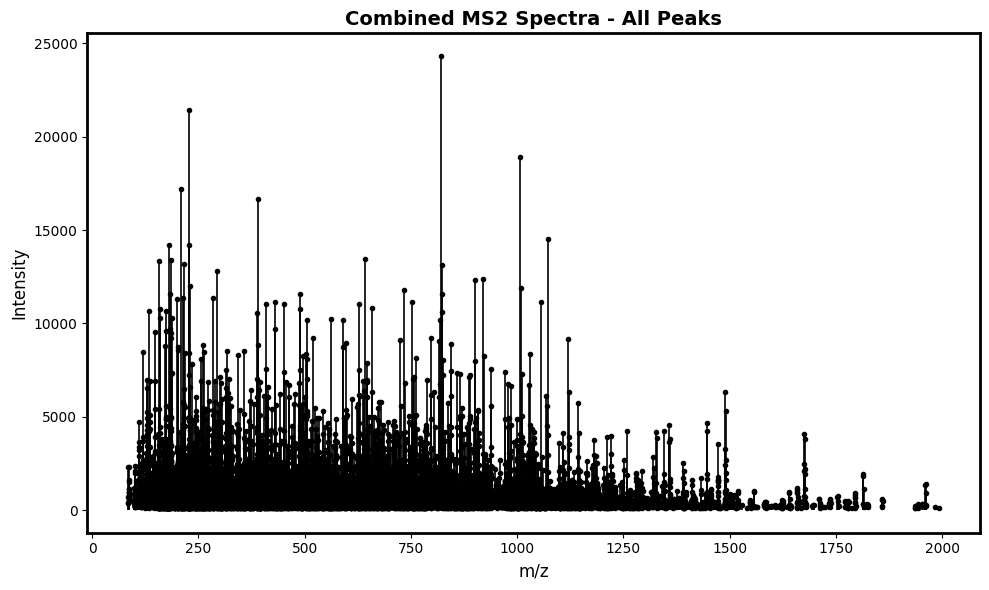

In [8]:
# Let's combine all m/z and intensity values from all spectra into single arrays
sum_mz = []
sum_int = []
for ms2 in get_all_MS2_objects(mzml_path):
    sum_mz.extend(ms2.mz)
    sum_int.extend(ms2.intensity)

print(f"Total peaks from all spectra: {len(sum_mz)}")
print(f"m/z range: {min(sum_mz):.2f} to {max(sum_mz):.2f}")

plot_multiple_MS2(sum_mz, sum_int, 
                  title="Combined MS2 Spectra - All Peaks", 
                  xlabel="m/z", 
                  ylabel="Intensity")

We've taken our mzml file, outputted every MS2 spectrum, and overlayed it in one graph.

There must be _hundreds_ of collisions happening between m/zs rounding down to the same integer.

In [9]:
def plot_multiple_MS2(x, y, title="Line Plot", xlabel="X-axis", ylabel="Y-axis", figsize=(10, 6)):
    """
    Create a line plot from x,y arrays using matplotlib.
    
    Parameters:
    x: array-like, x-coordinates
    y: array-like, y-coordinates  
    title: str, plot title
    xlabel: str, x-axis label
    ylabel: str, y-axis label
    figsize: tuple, figure size (width, height)
    """
    
    # Create the figure and axis
    plt.figure(figsize=figsize)
    
    # Create the line plot
    plt.plot(x, y, linewidth=1.5, color='blue')
    
    # Customize the plot to match plot_MS2 style
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    # Add grid for better readability
    plt.grid(True, alpha=0.3)
    
    # Set background color to white and add borders like plot_MS2
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(True)
    plt.gca().spines['right'].set_visible(True)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.gca().spines['top'].set_linewidth(2)
    plt.gca().spines['right'].set_linewidth(2)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()  # Only plot first 5 to avoid overhwelming output.


### Can we get a plot where collisions are color coded?

**Why use more precise m/z indices?**

If we had 200 unique m/z values ranging from 100–300 and rounded each to the nearest integer, we’d quickly run into overlaps. For example, every value between 128.5 ≤ m/z < 129.5 would collapse into the same index: 129. That means different peaks could get “bucketed” together, and we'd lose resolution.

To avoid this, we can create finer-grained buckets:
* Nearest 1.0 → array length = max(mz)
* Nearest 0.1 → array length ≈ max(mz) * 10
* Nearest 0.001 → array length ≈ max(mz) * 1000

So if max(mz) = 880, then:
* 0.1 precision → 8,800 buckets
* 0.001 precision → 880,000 buckets

Increased precision = bigger arrays. At very high precision (like 880k slots), things become computationally expensive and impractical, even if they are technically more accurate. We'll try a slightly different approach, one that better follows the actual paper.

In [10]:
# @title Open this cell for step 1
import math

WIDTH_OF_BIN = 0.01
LENGTH = int(max(spectrum_mz) // WIDTH_OF_BIN +1) # integer rounding up one.
print(f"We have to fit our m/zs into bins by rounding them to the nearest {WIDTH_OF_BIN}")
print(f"The length of our (simulated) array is {LENGTH}")

def to_idx(num): # whClusteringere num = mz val
    """
    Convert m/z value to a sparse vector index.

    This implements STEP 1 from the theoretical framework:
    "Convert the spectrum to a sparse vector using small mass bins"

    We divide m/z by 0.01 to create bins of 0.01 Da width.
    For example: 129.103 m/z → index 12910
    This creates fine-grained bins that preserve mass accuracy.
    """
    return int(num // WIDTH_OF_BIN) # round to third decimal and return the result. int since these will be 0 based indices


# IMPORTANT BELOW
# Create the sparse representation: map from m/z indices to intensities
# This is our "sparse vector" - instead of a huge array with mostly zeros,
# we only store the non-zero entries in a dictionary
mz_intensity_map = {}
# Populate the sparse vector with our spectrum data
for i, mz in enumerate(spectrum_mz):
    # Convert each m/z to its corresponding index and store the intensity
    mz_intensity_map[to_idx(mz)] = spectrum_int[i]

# Pretty print the map dictionary
print("The map dictionary looks like:")
print(f"m/z bin: intensity")
for idx, intensity in sorted(mz_intensity_map.items()):
    print(f"  {idx}: {intensity:.3f} ")
print("Where we only keep the nonzero values from our \"simulated array\"")
print(spectrum_mz[0], "rounds to",to_idx(spectrum_mz[0]))
# outputs: 129.10374450683594 12910

# Verify our expected index correctly matches our intensity (see mz and intensity arrays).
# expectedValue = map[to_idx(spectrum_mz[0])]
# assert math.isclose(expectedValue, 2174.818, abs_tol=0.001) # This is best practice for comparing floating pts

# Example of what our sparse vector looks like conceptually: 2174.818
# sparse_index → intensity
# 12910 → 2174.818  (from m/z 129.104)
# 14711 → 3145.84   (from m/z 147.114)
# 18516 → 9230.925  (from m/z 185.167)
# ...
#
# This avoids creating a massive array of ~880,000 zeros with just ~24 non-zero values!


We have to fit our m/zs into bins by rounding them to the nearest 0.01
The length of our (simulated) array is 87551
The map dictionary looks like:
m/z bin: intensity
  12910: 2174.818 
  14711: 3145.840 
  18516: 9230.925 
  18617: 2883.776 
  21316: 4380.564 
  22912: 2282.987 
  26020: 3063.123 
  29814: 2072.459 
  30015: 3142.870 
  32819: 2672.693 
  34723: 5380.330 
  34823: 2240.397 
  46226: 6059.931 
  46326: 2831.662 
  48420: 2237.599 
  57534: 3632.963 
  64638: 4356.975 
  64738: 2494.957 
  74340: 2366.822 
  76141: 8133.106 
  76241: 5098.785 
  76341: 2226.692 
  87449: 4098.929 
  87550: 2766.674 
Where we only keep the nonzero values from our "simulated array"
129.10374450683594 rounds to 12910


In [11]:
# @title Open this cell for Step 2
# STEP 2 from theoretical framework: Hash the high-dimensional sparse vector
# to a lower-dimensional vector using a hash function

hash_buckets = 800  # Our target dimensionality (much smaller than ~880k sparse indices)

def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 399)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')

    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % hash_buckets

# Initialize our final feature 
# This is our compact, fixed-size representation of the spectrum
hash_matrix = [0] * hash_buckets  # Start with all zeros

# The final step: populate the hash buckets with intensities
# Multiple sparse indices may hash to the same bucket (collisions)
# We handle collisions by ADDING intensities (preserving total signal)

# see how map allows us to not have to look through every bin?
for sparse_idx, intensity in mz_intensity_map.items(): 
    # Get the hash bucket for this sparse index
    bucket_idx = hasher(sparse_idx)

    # Add the intensity to the bucket (handles collisions by summation)
    hash_matrix[bucket_idx] += intensity

print("Final spectral hash vector:")

end = "["
for hashedVals in hash_matrix:
    if hashedVals != 0:
        end += f"{hashedVals:.2f},"
    if hashedVals ==0:
        end += f"{hashedVals},"
end = end[:len(end)-1]
print(end,end="]\n")
print("Non-zero buckets:", sum(1 for x in hash_matrix if x > 0), f"out of {hash_buckets} buckets" )

Final spectral hash vector:
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3142.87,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2072.46,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2883.78,0,2282.99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4356.98,0,0,0,0,0,0,0,0,0,0,0,2366.82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2240.40,0,0,0,0,2226.69,0,0,0,0,0,0,0,0,0,2494.96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4380.56,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3145.84,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2766.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8133.11,0,0,0,2237.60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2831.66,0,0,0,0,0,0,0,0,0,0,0

**SUMMARY** of the spectral hashing process:
1. Started with: 24 (m/z, intensity) pairs
2. Essentially to: ~88,000 possible sparse indices, only 24 actually used
3. Hashed down to: 800 compact feature dimensions
4. Result: Fixed-size vector that preserves spectral similarity for ML/clustering

What does it mean to **preserve similarity?**

Maintaining the relative closeness between spectra after hashing, so you can perform clustering or nearest neighbor search without needing the full 88,000-dimensional sparse vector.

Two vectors $\vec{x}$ and $\vec{z}$ are more similar than $\vec{x}$ and $\vec{y}$ if their dot product, is greater than the latter.

$\vec{x} \cdot \vec{z} > \vec{x} \cdot \vec{y} $


Preserving similarity across your spectra means that once you hash it, it should still maintain about the same dot product across all values as when you bin it. 

Of course, there'll be a few more inconsistencies as you're going from 8800 $\rightarrow$ 800 dimensions, but it should be relatively the same.


Similarity Preservation Analysis:
Cosine similarity between sparse and hash similarities: 0.892
This shows how well the hash representation preserves the similarity structure
A similarity close to 1 indicates good similarity preservation
shape of correlation matrix: (2, 2) shape of other arrays: (414, 414) (414, 414)


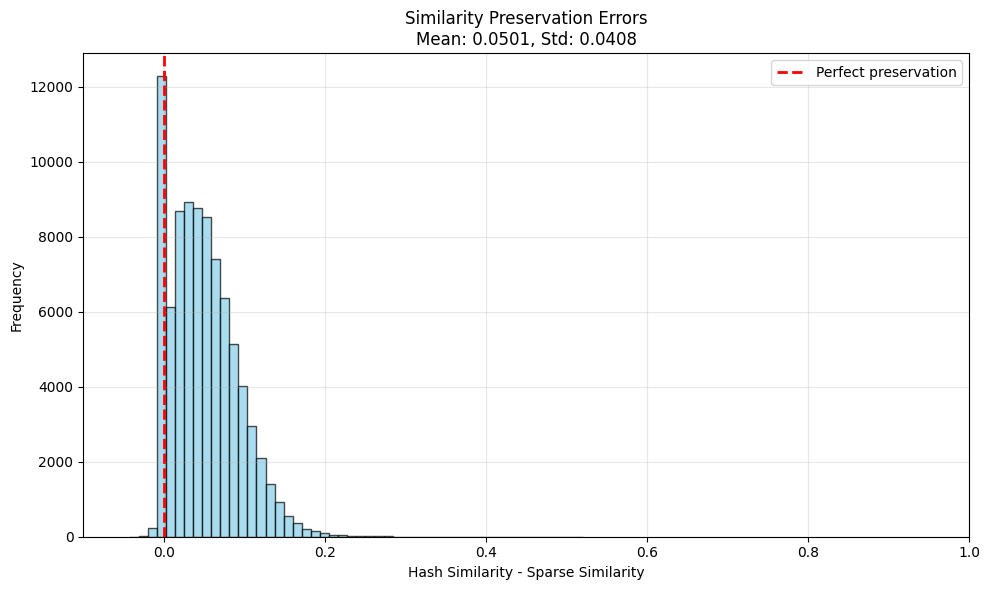


Detailed Statistics:
Number of pairwise comparisons: 85,491
Sparse similarities range: 0.000 to 0.933
Hash similarities range: 0.000 to 0.936
Mean absolute difference: 0.0504
Pearson correlation coefficient: 0.8716
Clustering based on unhashed similarities, showing both matrices with same ordering:


c:\Users\Alex\Source\Repos\MS_spectra_encoding\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

c:\Users\Alex\Source\Repos\MS_spectra_encoding\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



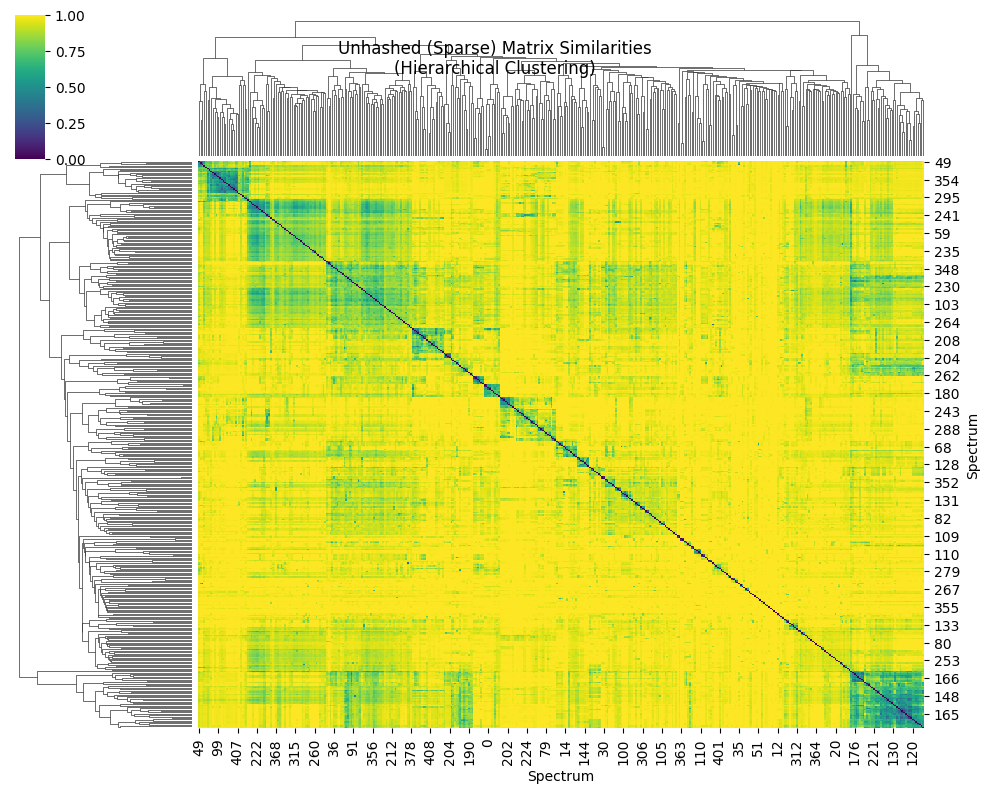

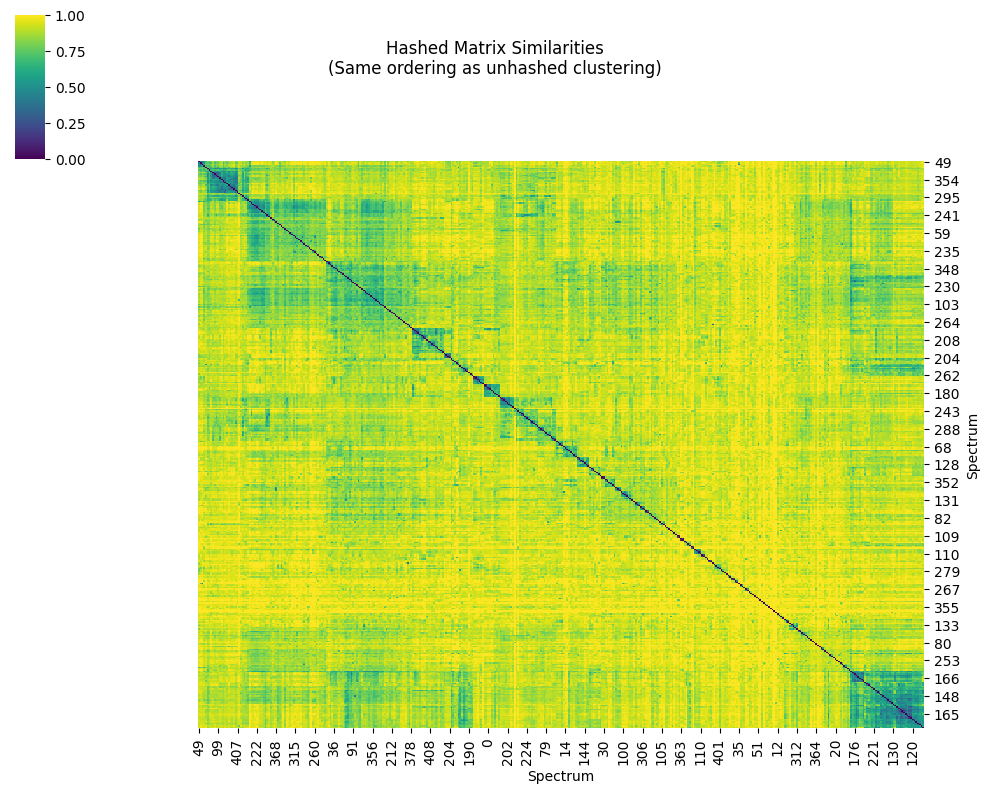

In [12]:
# Demonstrate similarity preservation between original sparse maps and hashed vectors
# Let's get multiple spectra and compare their similarities
from functools import lru_cache
# Get all spectra first

spectra_to_compare = get_all_MS2_objects("04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML")

# Convert each spectrum to sparse map and hash vector representations
sparse_maps = []
hash_vectors = []

WIDTH_OF_BIN = 0.01
hash_buckets = 800

def normalize_intensity():
    """Normalize intensities across all spectra to range [0,1]"""
    # Collect all intensities from all spectra
    all_intensities = []
    for ms2 in spectra_to_compare:
        all_intensities.extend(ms2.intensity)
    
    max_int = max(all_intensities)
    min_int = min(all_intensities)
    
    def normalize_formula(intensity_array):
        res = []
        for intensity in intensity_array:
            int = (intensity - min_int) / (max_int - min_int)
            res.append(int)
        return res
    # Create normalized spectra tuples (mz, normalized_intensity)
    normalized_spectra = []
    for ms2 in spectra_to_compare:
        normalized_intensities = normalize_formula(ms2.intensity)
        # Create tuple of (mz_array, normalized_intensity_array)
        normalized_spectrum = (ms2.mz, normalized_intensities)
        normalized_spectra.append(normalized_spectrum)
    
    return normalized_spectra

# Get normalized data
normalized_spectra_tuples = normalize_intensity()

# Mutate spectra_to_compare to use normalized data
spectra_to_compare = [
    type('NormalizedSpectrum', (), {
        'mz': mz_array, 
        'intensity': intensity_array
    })() 
    for mz_array, intensity_array in normalized_spectra_tuples
]


def create_sparse_map(mz_array, intensity_array): # same as our code above.
    """Convert spectrum to sparse map representation"""
    sparse_map = {}
    for mz, intensity in zip(mz_array, intensity_array):
        idx = int(mz // WIDTH_OF_BIN)
        sparse_map[idx] = intensity
    return sparse_map

def sparse_map_to_hash_vector(sparse_map, num_buckets=hash_buckets):
    """Convert sparse map to hash vector"""
    hash_vec = [0] * num_buckets
    for sparse_idx, intensity in sparse_map.items():
        byte_representation = int(sparse_idx).to_bytes(8, 'little')
        bucket_idx = rapidhash(byte_representation) % num_buckets
        hash_vec[bucket_idx] += intensity
    return hash_vec
def cosine_similarity(vec1, vec2):
    """Calculate cosine similarity between two vectors (returns value between 0 and 1)"""
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    
    # Calculate dot product
    dot_prod = np.dot(vec1, vec2)
    
    # Calculate magnitudes
    norm1 = np.linalg.norm(vec1) # here's the "cosine" part of cosine_similarity
    norm2 = np.linalg.norm(vec2)
    
    # Avoid division by zero
    if norm1 == 0 or norm2 == 0:
        return 0.0
    
    # Cosine similarity = dot_product / (norm1 * norm2)
    return dot_prod / (norm1 * norm2)
def sparse_cosine_similarity(map1, map2):
    """Calculate cosine similarity between two sparse maps (returns value between 0 and 1)"""
    # Get all unique indices from both maps
    all_indices = set(map1.keys()) | set(map2.keys())
    
    # Convert sparse maps to dense vectors for the shared indices

    vec1 = np.array([map1.get(idx, 0.0) for idx in sorted(all_indices)])
    vec2 = np.array([map2.get(idx, 0.0) for idx in sorted(all_indices)])
    # Calculate cosine similarity using the dot_product function
    return cosine_similarity(vec1, vec2)

# Create representations for each spectrum
for spec_data in spectra_to_compare:
    sparse_map = create_sparse_map(spec_data.mz, spec_data.intensity)
    hash_vec = sparse_map_to_hash_vector(sparse_map,hash_buckets)
    
    sparse_maps.append(sparse_map)
    hash_vectors.append(hash_vec)

# Calculate similarity matrices

n_spectra = len(spectra_to_compare)
sparse_similarities = np.zeros((n_spectra, n_spectra)) # tuples
hash_similarities = np.zeros((n_spectra, n_spectra))

# Calculate pairwise similarities using cosine similarity
for i in range(n_spectra):
    for j in range(n_spectra):
        # Sparse map cosine similarities (0 to 1)
        sparse_similarities[i, j] = sparse_cosine_similarity(sparse_maps[i], sparse_maps[j])
        
        # Hash vector cosine similarities (0 to 1)  
        hash_similarities[i, j] = cosine_similarity(hash_vectors[i], hash_vectors[j])


# When you compute pairwise similarities between spectra, you get a symmetric matrix
#      Spec0  Spec1  Spec2  Spec3
# Spec0  1.0   0.8    0.3    0.6
# Spec1  0.8   1.0    0.4    0.5
# Spec2  0.3   0.4    1.0    0.7
# Spec3  0.6   0.5    0.7    1.0
#
# Using np.triu allows us to just grab the upper (right) triangle. np.tril_indices would grab the lower left.
#
# Show distance between sparse and hash similarities using cosine distance
sparse_upper = sparse_similarities[np.triu_indices(n_spectra, k=1)]
hash_upper = hash_similarities[np.triu_indices(n_spectra, k=1)]

import numpy as np
from scipy.spatial import distance
import pandas as pd

# Calculate cosine distance between the similarity matrices
cosine_similarity_preservation = 1- distance.cosine(sparse_upper, hash_upper)
correlation = np.corrcoef(sparse_upper, hash_upper)

print(f"\nSimilarity Preservation Analysis:")
print(f"Cosine similarity between sparse and hash similarities: {cosine_similarity_preservation:.3f}")
print(f"This shows how well the hash representation preserves the similarity structure")
print(f"A similarity close to 1 indicates good similarity preservation")
print("shape of correlation matrix:", correlation.shape, "shape of other arrays:", sparse_similarities.shape, hash_similarities.shape)

# Create multiple cleaner visualizations instead of one overwhelming scatter plot
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# Difference histogram - shows how well similarities are preserved
differences = hash_upper - sparse_upper
axes.hist(differences, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect preservation')
axes.set_xlabel('Hash Similarity - Sparse Similarity')
axes.set_ylabel('Frequency')
axes.set_title(f'Similarity Preservation Errors\nMean: {np.mean(differences):.4f}, Std: {np.std(differences):.4f}')
axes.legend()
axes.set_xlim(-0.1, 1.0)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nDetailed Statistics:")
print(f"Number of pairwise comparisons: {len(sparse_upper):,}")
print(f"Sparse similarities range: {np.min(sparse_upper):.3f} to {np.max(sparse_upper):.3f}")
print(f"Hash similarities range: {np.min(hash_upper):.3f} to {np.max(hash_upper):.3f}")
print(f"Mean absolute difference: {np.mean(np.abs(differences)):.4f}")
print(f"Pearson correlation coefficient: {correlation[0,1]:.4f}")

# Convert sparse similarities to DataFrame for better display
sparse_df = pd.DataFrame(sparse_similarities)
sparse_df.index.name = 'Spectrum'
sparse_df.columns.name = 'Spectrum'

# Convert hash similarities to DataFrame for better display  
hash_df = pd.DataFrame(hash_similarities)
hash_df.index.name = 'Spectrum'
hash_df.columns.name = 'Spectrum'

import seaborn as sns

# Perform hierarchical clustering on the sparse (unhashed) similarities
# Convert similarity to distance (1 - similarity) for clustering
sparse_distances = 1 - sparse_similarities

# Create clustermaps with the same ordering
print("Clustering based on unhashed similarities, showing both matrices with same ordering:")

# First clustermap: sparse similarities (this determines the ordering)
fig1 = sns.clustermap(1-sparse_df, method="average", cmap="viridis", 
                      figsize=(10, 8), cbar_pos=(0.02, 0.8, 0.03, 0.18))
fig1.figure.suptitle('Unhashed (Sparse) Matrix Similarities\n(Hierarchical Clustering)', y=0.95)

# grab ordering from fig 1
row_order = fig1.dendrogram_row.reordered_ind
col_order = fig1.dendrogram_col.reordered_ind

plt.show()

# Reorder the hash_df according to the clustering results from fig 1
hash_df_reordered = hash_df.iloc[row_order, col_order]

fig2 = sns.clustermap(1-hash_df_reordered, method="average", cmap="viridis",
                      row_cluster=False, col_cluster=False,  # Don't re-cluster, use existing order
                      figsize=(10, 8), cbar_pos=(0.02, 0.8, 0.03, 0.18))
fig2.figure.suptitle('Hashed Matrix Similarities\n(Same ordering as unhashed clustering)', y=0.95)

plt.show()

## Spectral Hashing Example, Start to Finish

### Set-Up/Background

Below is the ion ladder for the peptide: AVVQDPALKPLALVYGEATSR.

In [ ]:
make_ion_ladder('AVVQDPALKPLALVYGEATSR', aa_mass)

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,72.044114,A,VVQDPALKPLALVYGEATSR,2127.179698,20
1,2,171.112528,AV,VQDPALKPLALVYGEATSR,2028.111284,19
2,3,270.180942,AVV,QDPALKPLALVYGEATSR,1929.042870,18
3,4,398.239520,AVVQ,DPALKPLALVYGEATSR,1800.984292,17
4,5,513.266463,AVVQD,PALKPLALVYGEATSR,1685.957349,16
5,6,610.319227,AVVQDP,ALKPLALVYGEATSR,1588.904585,15
6,7,681.356341,AVVQDPA,LKPLALVYGEATSR,1517.867471,14
7,8,794.440405,AVVQDPAL,KPLALVYGEATSR,1404.783407,13
8,9,922.535368,AVVQDPALK,PLALVYGEATSR,1276.688444,12
9,10,1019.588132,AVVQDPALKP,LALVYGEATSR,1179.635680,11


Let's look at how this ion ladder can be plotted as a "spectrum." The purpose of this is to visualize the spread of m/z values. The intensity values here are meaningless.

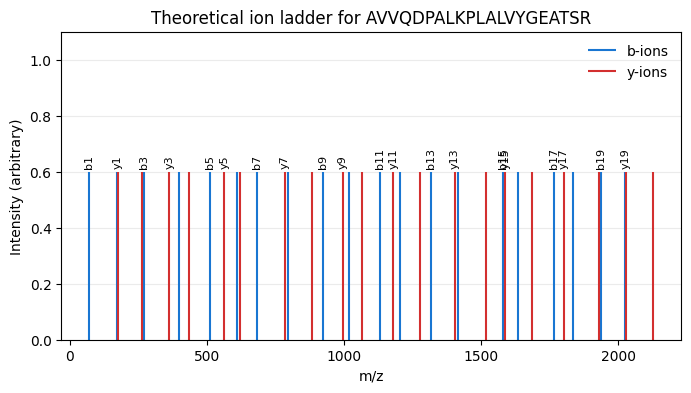

In [ ]:
b_mz = [
    72.044114, 171.112528, 270.180942, 398.239520, 513.266463,
    610.319227, 681.356341, 794.440405, 922.535368, 1019.588132,
    1132.672196, 1203.709310, 1316.793374, 1415.861788, 1578.925108,
    1635.946572, 1764.989165, 1836.026279, 1937.073958, 2024.105986
]

y_mz = [
    2127.179698, 2028.111284, 1929.042870, 1800.984292, 1685.957349,
    1588.904585, 1517.867471, 1404.783407, 1276.688444, 1179.635680,
    1066.551616, 995.514502, 882.430438, 783.362024, 620.298704,
    563.277240, 434.234647, 363.197533, 262.149854, 175.117826
]

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

# Equal heights (e.g., 1.0)
height = 0.6
ax.vlines(b_mz, 0, height, colors='#1976D2', linewidth=1.5, label='b-ions')
ax.vlines(y_mz, 0, height, colors='#D32F2F',  linewidth=1.5, label='y-ions')

ax.set_ylim(0, 1.1)
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity (arbitrary)")
ax.set_title("Theoretical ion ladder for AVVQDPALKPLALVYGEATSR")
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.25)

# b labels: b1, b3, b5, ...
for i, x in enumerate(b_mz, start=1):
    if i % 2 == 1:
        ax.text(x, height*1.02, f"b{i}", rotation=90, ha="center", va="bottom", fontsize=8)

# y_mz is descending (y20..y1). Convert to ion number j = y#
n_y = len(y_mz)
for i, x in enumerate(y_mz, start=1):
    j = n_y - i + 1   # y ion number at this m/z
    if j % 2 == 1:    # y1, y3, y5, ...
        ax.text(x, height*1.02, f"y{j}", rotation=90, ha="center", va="bottom", fontsize=8)

plt.show()

Now that we've visualized this theoretical ion ladder as a "spectrum," let's plot a real spectrum and use the ion ladder to annotate it. The spectrum plotted below is the unmodified AVVQDPALKPLALVYGEATSR peptide.

In [ ]:
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'
plot_MS2(get_MS2_object(mzml_path, 9970, peptide = 'AVVQDPALKPLALVYGEATSR')) # Scan 9970 is the unmodified spectrum for sequence AVVQDPALKPLALVYGEATSR

Although there is inevitable noise that deviates from the theoretical ion ladder, this spectrum overall aligns really well with the ladder. In other words, **a significant proportion of this spectrum's total intensity is accounted for by the theoretical ion ladder.** Let's now look at a modified version of AVVQDPALKPLALVYGEATSR.

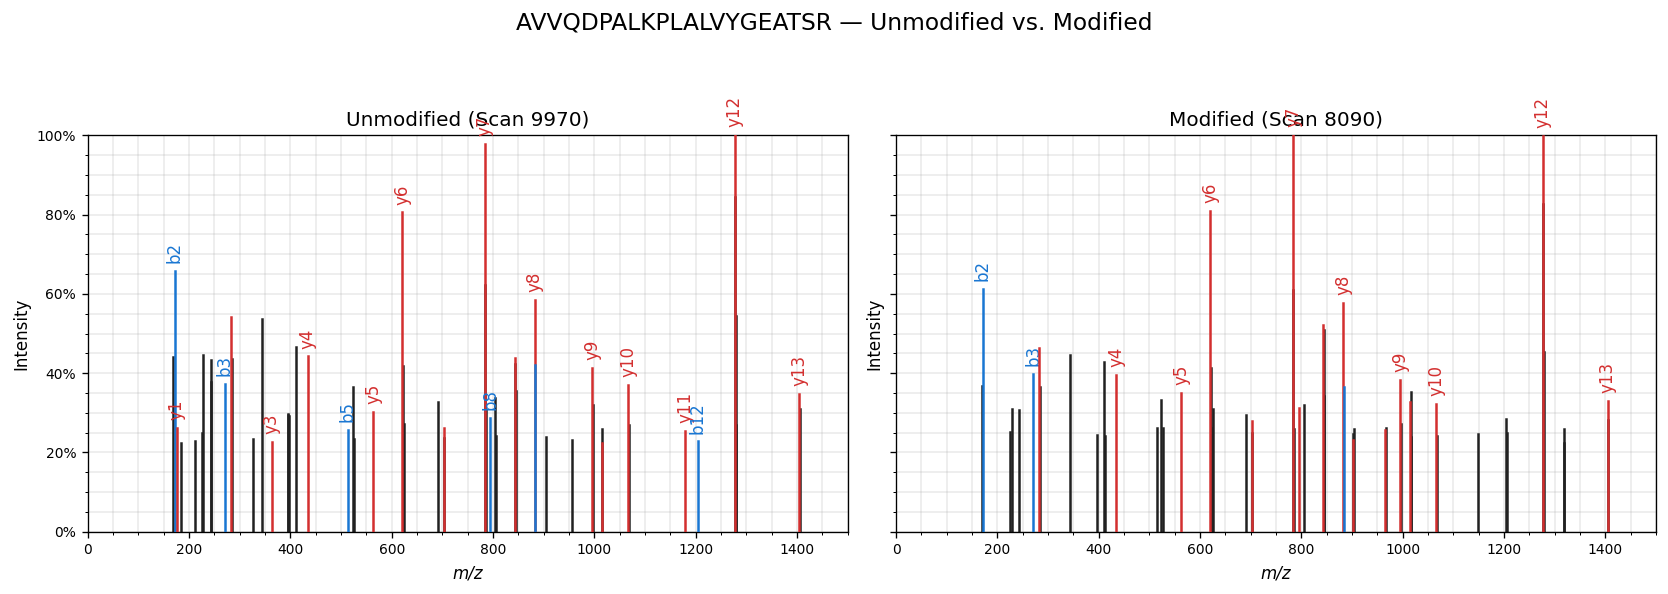

In [ ]:

seq = 'AVVQDPALKPLALVYGEATSR'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 9970, peptide=seq)
spec_right = get_MS2_object(mzml_path, 8090, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = unmodified = scan 9970
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 9970)")

# Right panel = modified = scan 8090
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8090)")

fig.suptitle("AVVQDPALKPLALVYGEATSR — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

We can repeat that process using an unmodified and modified spectrum from each of the 2 other peptides in our mzml file: IITHPNFNGNTLDNDIMLIK and RMVNNGHSFNVEYDDSQDK.

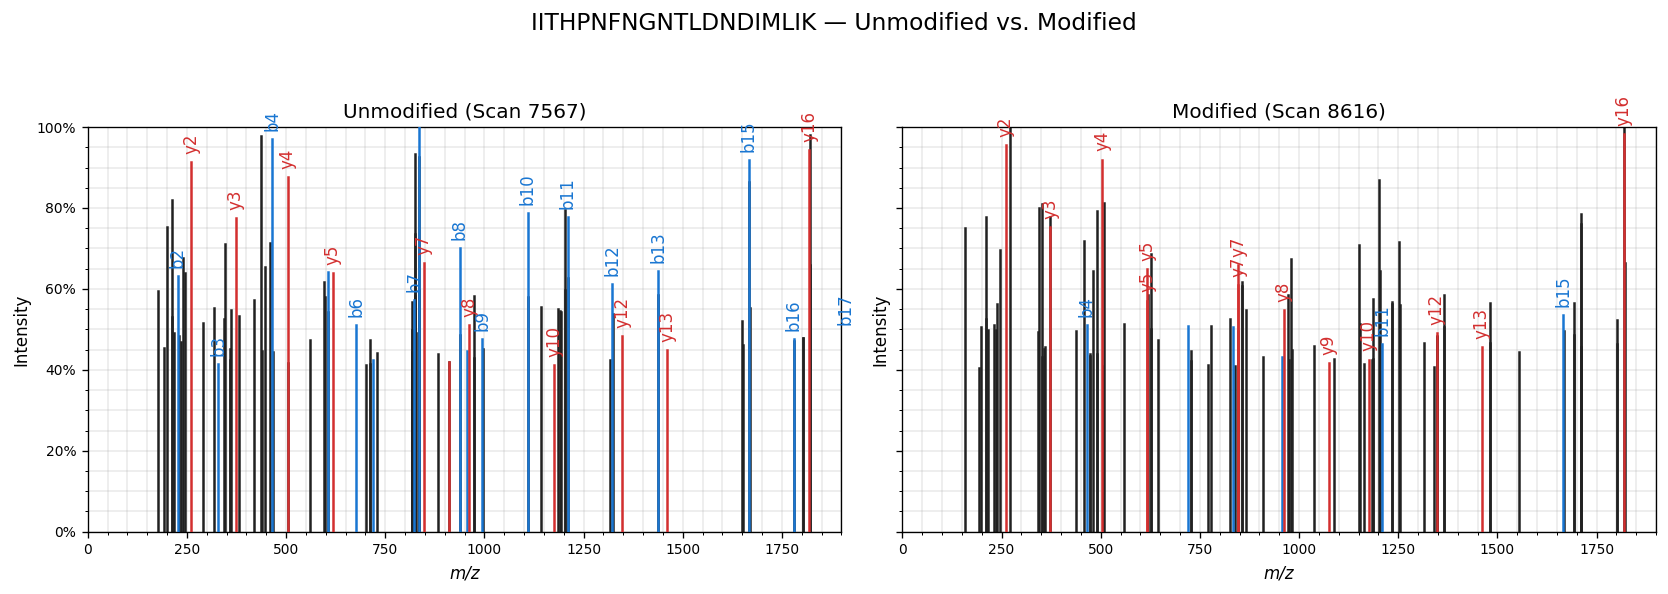

In [ ]:

seq = 'IITHPNFNGNTLDNDIMLIK'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'
spec_left  = get_MS2_object(mzml_path, 7567, peptide=seq)
spec_right = get_MS2_object(mzml_path, 8616, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = unmodified = scan 7567
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 7567)")

# Right panel = modified = scan 8616
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8616)")

fig.suptitle("IITHPNFNGNTLDNDIMLIK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

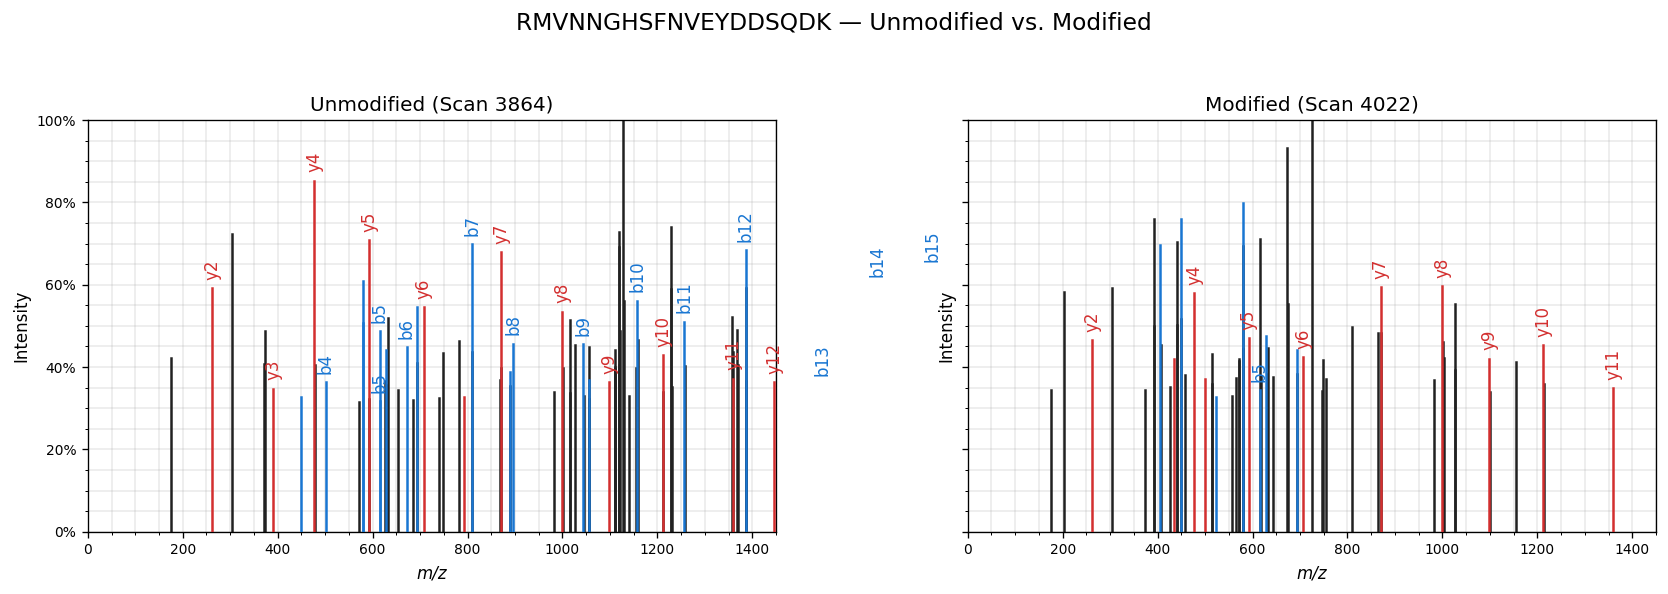

In [ ]:

seq = 'RMVNNGHSFNVEYDDSQDK'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 3864, peptide=seq)
spec_right = get_MS2_object(mzml_path, 4022, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = unmodified = scan 3864
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 3864)")

# Right panel = modified = scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 4022)")

fig.suptitle("RMVNNGHSFNVEYDDSQDK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

There are two "trends" you might be noticing by now: <br></br>
1. Generally, when a spectrum (modified or unmodified) is annotated with the theoretical ion ladder for it's associated peptide, there is a significant proportion of that spectrum's intensity that is accounted for by the ion ladder.
2. Unmodified spectra better "match" or are better "accounted for" by the peptide's theoretical ion ladder than modified spectra. But there is not a significant difference.
<br></br>
But what if we were to use the ion ladder of one peptide to annotate the spectrum of a different peptide? Let's try using the theoretical ion ladder of AVVQDPALKPLALVYGEATSR to annotate the spectrum of a modified RMVNNGHSFNVEYDDSQDK peptide. We'll plot that on the right panel. On the left, we'll plot the spectrum of a modified AVVQDPALKPLALVYGEATSR spectrum and annotate it with the AVVQDPALKPLALVYGEATSR ion ladder (just as we did above). In this case, we are plotting spectra from **2 different peptides** and annotating them with **1 ion ladder.**

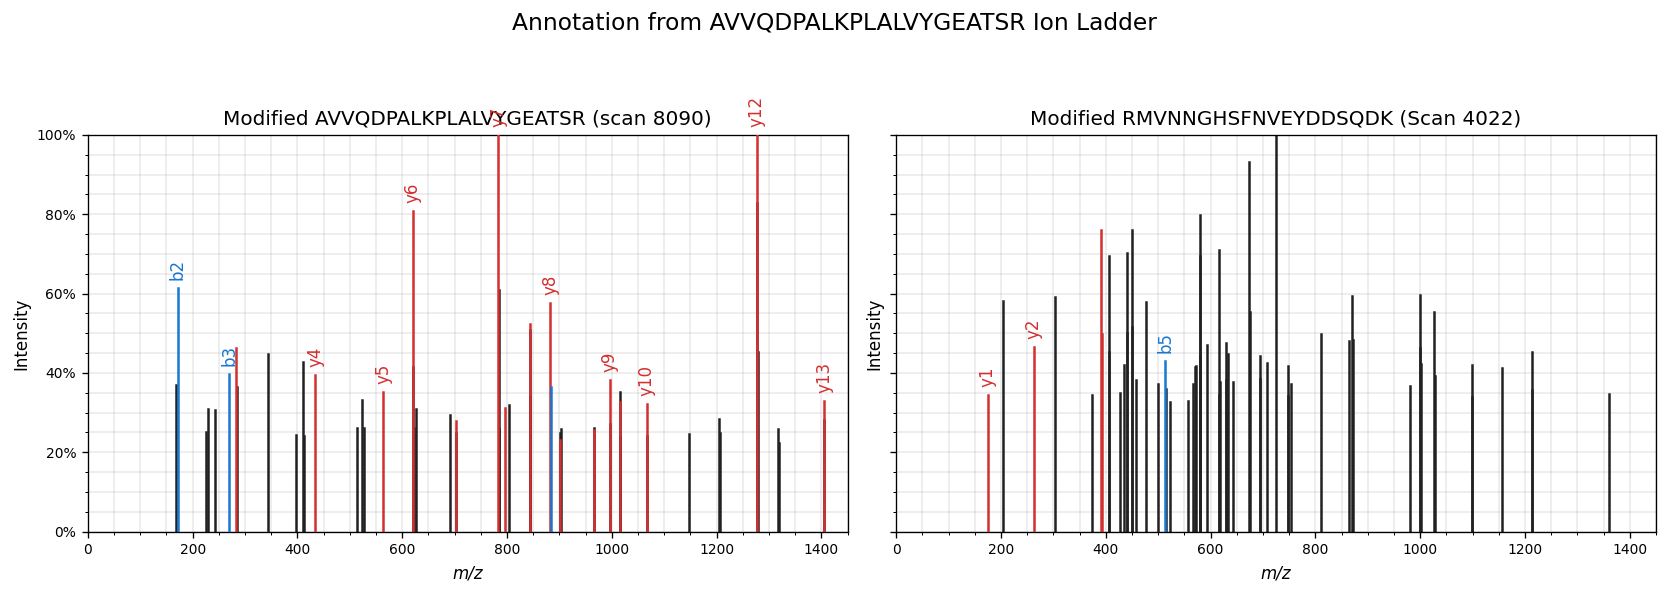

In [ ]:
seq = 'AVVQDPALKPLALVYGEATSR'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 8090, peptide=seq)
spec_right = get_MS2_object(mzml_path, 4022, peptide=seq)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = modified AVVQDPALKPLALVYGEATSR = scan 8090
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Modified AVVQDPALKPLALVYGEATSR (scan 8090)")

# Right panel = modified RMVNNGHSFNVEYDDSQDK = scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified RMVNNGHSFNVEYDDSQDK (Scan 4022)")

fig.suptitle("Annotation from AVVQDPALKPLALVYGEATSR Ion Ladder", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Let's do that once more, but this time annotating the spectrum of the modified RMVNNGHSFNVEYDDSQDK peptide using the theoretical ion ladder of RMVNNGHSFNVEYDDSQDK (on the left) and AVVQDPALKPLALVYGEATSR (on the right). In this case, we are plotting **1 spectrum** and annotating it with **2 different ion ladders.**

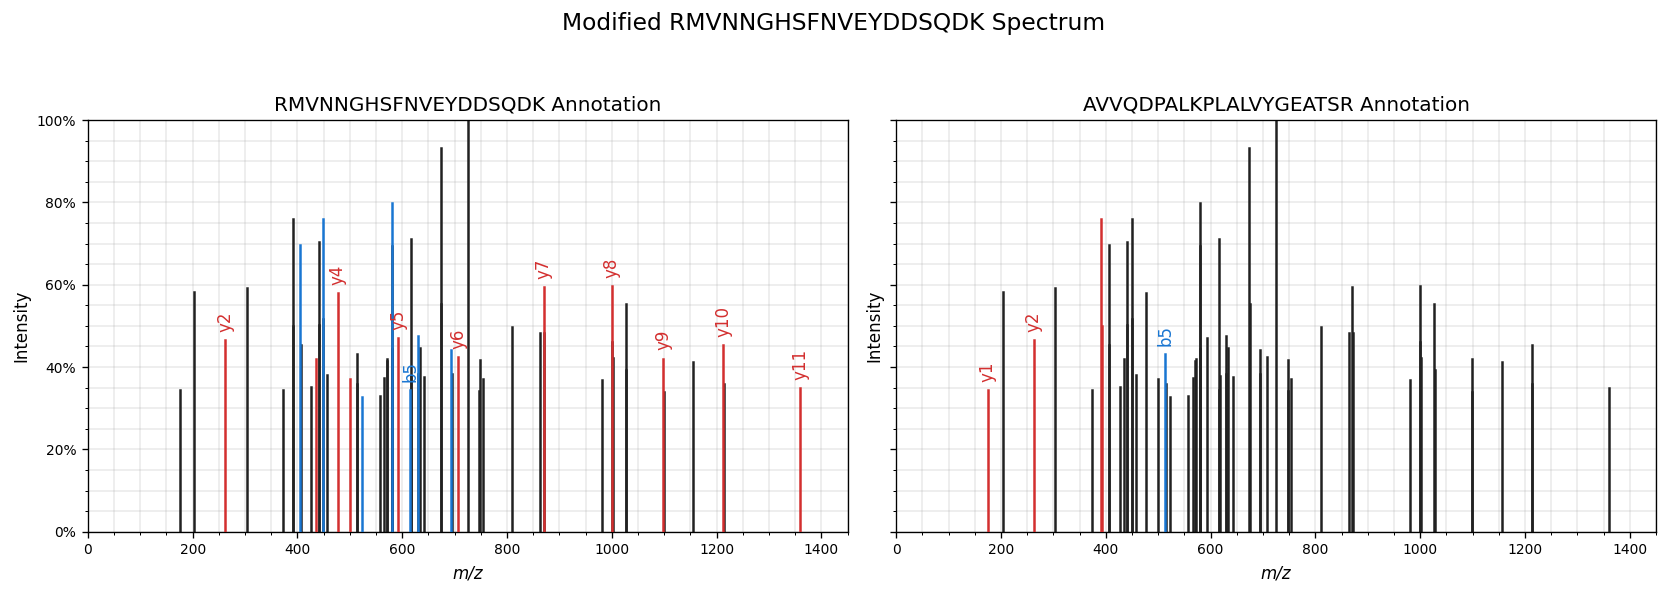

In [ ]:
seq_1= 'RMVNNGHSFNVEYDDSQDK'
seq_2 = 'AVVQDPALKPLALVYGEATSR'
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML'

spec_left  = get_MS2_object(mzml_path, 4022, peptide=seq_1)
spec_right = get_MS2_object(mzml_path, 4022, peptide=seq_2)

# Make two panels sharing axes so scales match
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = RMVNNGHSFNVEYDDSQDK Annotation, Scan 4022
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("RMVNNGHSFNVEYDDSQDK Annotation")

# Right panel = AVVQDPALKPLALVYGEATSR Annotation, scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("AVVQDPALKPLALVYGEATSR Annotation")

fig.suptitle("Modified RMVNNGHSFNVEYDDSQDK Spectrum", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Now, you're probably beginning to notice more meaningful trends. In the first example, where we annotated two different spectra (from different peptides) with the same ion ladder, a much greater proportion of the "matching" spectrum's intensity was accounted for by the ion ladder than of the other spectrum's intensity. In the second example, where we annotated the same spectrum using two different ion ladders (one belonging to the same peptide, and one not), a much greater proportion of the spectrum (annotated by it's associated peptide)'s intensity was accounted for by the ion ladder than of the spectrum (annoted by the other peptide)'s intensity. **Let's begin the binning process:**

In [ ]:

import importlib
import SpectrumWithTransformations as swt_module
import SpectrumWithTransformations
from spectrum_utils.proforma import Modification

importlib.reload(swt_module)

# This function should read in an mzml file and return an object of type SpectrumWithTransformations
# Based off of get_MS2_object from Sam Payne lesson 4
def get_SWT_object(
    mzml_path: str,
    scan_number: int,
    full_sequence = None,
) -> "SpectrumWithTransformations":
    
    index = scan_number -1 #scan_number is 1-based, index is 0-based
    with mzml.MzML(mzml_path, use_index=True) as reader: #use_index=True allows us to avoid reading through the entire mzml file
        selected_spectrum = reader.get_by_index(index)
    # Test to see if we accessed the correct scan: PASSED!
    # precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    # print(precursor_mz)
    

    # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
    spectrum_id = selected_spectrum['id']
    retention_time = selected_spectrum['scanList']['scan'][0]['scan start time']
    precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    precursor_charge = int(selected_spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])
    mz_array = np.asarray(selected_spectrum['m/z array'])
    intensity_array = np.asarray(selected_spectrum['intensity array'])
    
    swt_object = SpectrumWithTransformations.SpectrumWithTransformations(
        identifier=spectrum_id,
        scan_number=scan_number,
        precursor_mz=precursor_mz,
        precursor_charge=precursor_charge,
        mz_array=mz_array,
        intensity_array=intensity_array,
        retention_time=retention_time,
        annotation_dictionary=None,
        binned_mz=None,
        hashed_mz=None,
    )

    if full_sequence:
        swt_object = swt_object.annotate_proforma(
            proforma_str = full_sequence,
            fragment_tol_mass = 0.01, # We consider two peaks (actual and theoretical) "equivalent" if they are within +/- 0.01 Da
            fragment_tol_mode = 'Da',
            ion_types = 'by',
            max_ion_charge = max(1, precursor_charge - 1)
        )
    return swt_object

In [ ]:
# from spectrum_utils.proforma import Modification
# Example with Scan 8090
# mod_1 = Modification(  
    # mass = 0.9848,
    # position = 4,
    # label = 'Deamidation'
# )
# modifications_list = [mod_1]

scan_8090 = get_SWT_object(
    mzml_path='04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML',
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)

plot_MS2(scan_8090, title='Scan 8090: Original Spectrum')

In [ ]:
WIDTH_OF_BIN = 0.01
def to_idx(num):
    return int(num // WIDTH_OF_BIN)

# Bin the mz
scan_8090.binned_mz = np.empty_like(scan_8090.mz, dtype=int)
for i in range(len(scan_8090.mz)):
    scan_8090.binned_mz[i] = to_idx(scan_8090.mz[i])

# Create a binned_spectrum SWT object for plotting purposes only
binned_spectrum = get_SWT_object(
    mzml_path='04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML',
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(binned_spectrum.mz)):
    binned_spectrum.mz[i] = scan_8090.binned_mz[i] #Re-writing the mz_array with the binned mz values

# Plot the binned spectrum
plot_MS2(binned_spectrum, 'Scan 8090: Binned Spectrum')


In [ ]:
hash_buckets = 800  # Target dimensionality

def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 399)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % hash_buckets

# Set-up
hashed_mz = []
hashed_intensity = []
hash_matrix = [0] * hash_buckets
mz_intensity_map = {}
for i, mz in enumerate(scan_8090.mz):
    mz_intensity_map[to_idx(mz)] = scan_8090.intensity[i]

# Hash the mz and add the intensities as we go
for sparse_idx, intensity in mz_intensity_map.items():
    bucket_idx = hasher(sparse_idx)
    hash_matrix[bucket_idx] += intensity
    hashed_mz.append(bucket_idx)
    hashed_intensity.append(hash_matrix[bucket_idx])

# Update the hashed mz and intensities
scan_8090.hashed_mz = hashed_mz
scan_8090.hashed_intensity = hashed_intensity

# Create a hashed_spectrum SWT object for plotting purposes only
hashed_spectrum = get_SWT_object(
    mzml_path='04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML',
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(hashed_spectrum.mz)):
    hashed_spectrum.mz[i] = scan_8090.hashed_mz[i] #Re-writing the mz_array with the hashed mz values
    hashed_spectrum.intensity[i] = scan_8090.hashed_intensity[i] #Re-writing the intensity_array with the summed intensity values

# Plot the hashed spectrum
plot_MS2(hashed_spectrum, 'Scan 8090: Hashed Spectrum')


/home/avni/source/repos/MS_spectra_encoding/.venv/lib64/python3.13/site-packages/plotly/matplotlylib/renderer.py:645: UserWarning:

Looks like the annotation(s) you are trying 
to draw lies/lay outside the given figure size.

Therefore, the resulting Plotly figure may not be 
large enough to view the full text. To adjust 
the size of the figure, use the 'width' and 
'height' keys in the Layout object. Alternatively,
use the Margin object to adjust the figure's margins.



### Side by side
<img src="Scan8090_Original.png" width="400" height="300">
<img src="Scan8090_Binned.png" width="400" height="300">
<img src="Scan8090_Hashed.png" width="400" height="300">